<a href="https://colab.research.google.com/github/solomon7-data/Athlete/blob/main/Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Import

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/solomon7-data/HIV_DATA1/main/HIV.csv', encoding='latin1')


In [ ]:

data = data.transpose().reset_index()
data.columns = data.iloc[1]
data = data.iloc[2:]
df = data
df[['Activity','Clients receiving HIV test results (at VCT)','Clients testing positive for HIV (at VCT)','Clients receiving HIV test results (at PITC)','Clients testing positive for HIV (at PITC)']]

1,Activity,Clients receiving HIV test results (at VCT),Clients testing positive for HIV (at VCT),Clients receiving HIV test results (at PITC),Clients testing positive for HIV (at PITC)
2,Meskerem 2018,134,1,716,4
3,Tikemet 2018,100,1,679,6
4,Hidar 2018,107,2,706,3
5,Tahesas 2018,144,5,741,6
6,Tir 2018,118,1,661,4
7,Yekatit 2018,119,4,806,12
8,Megabit 2018,105,1,675,NaN
9,Miazia 2018,119,NaN,675,3
10,Genbot 2018,128,2,781,3
11,Sene 2018,126,1,799,9


In [ ]:
df = data.fillna(0)

/tmp/ipykernel_1615/3551743364.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = data.fillna(0)


In [ ]:
rename_cols = {'Activity':'yr_mnth',
 'Clients receiving HIV test results (at VCT)':'VCT',
 'Clients testing positive for HIV (at VCT)':'VCT_Pos',
 'Clients receiving HIV test results (at PITC)':'PITC',
 'Clients testing positive for HIV (at PITC)':'PITC_Pos',
 'Number of index cases offered':'ICT_offered',
 'Number of contacts elicited':'Elicited',
 'Number of contacts tested':'ICT_Testd',
 'New positive':'ICT_Pos',
 'Known positive':'ICT_known',
 'HIV_Number of Individual HIV self test KIT distributed':'Self_Test',
 'HIV_Children currently on ART':'COA_Adult',
 'HIV_Adults currently on ART':'COA_Pedy',
 'HIV_Number of children (<19) who are currently on ART by regimen type':'COA_<19',
 'Number of adults and children with HIV infection newly started on ART':'TX_New',
 'Linkage outcome of newly identified Hiv positive individuals in the reporting period':'Linked',
 'Linked to Care and Treatment':'Initiated',
 'Known on ART':'known',
 'Lost to follow-up':'Lost',
 'Number of adult and pediatric ART patients for whom viral load test result received in the reporting period':'VL_Recieved',
 'Total number of adult and paediatric ART patients with an undetectable viral load(<50 copies/ml) in the reporting period':'supressed',
 'Total number of adult and paediatric ART patients with low level viremia (50 -1000 copies/ml) in the reporting period':'LVL',
 'Total number of clients on 3MMD':'3MMD',
 'Total number of clients on ASM(6MMD)':'ASM(6MMD)',
 'Total number of clients on FTAR':'FTAR',
 'Total number of clients on CAG':'CAG',
 'Total number of clients on PCAD':'PCAD',
 'Total number of clients on Adolescent DSD':'Adolescent DSD',
 'Total number of clients on KP DSD':'KP DSD',
 'Total number of clients on MCH DSD':'MCH DSD',
 'Total number of clients on other types of DSD':'Other_DSD',
 'Total number of clients on Advanced HIV Disease Care Model':'AHD',
 'Commercial sex workers':'CSW_1',
 'PrEP Curr (Number of individuals that received oral PrEP during the reporting period)':'PrEP',
 'By age and Sex':'Prep_Curr',
 'Number of STI cases tested for HIV':'STI_HIV',
 'Number of STI cases tested positive for HIV':'STI_HIV_Pos',
 'Proportion of patients enrolled in HIV care who were screened for TB (FD)':'TB_Screened',
 'Number of NEWLY Enrolled ART clients who were screened for TB during the reporting period':'TB_Screened_new',
 'Screened Positive for TB':'Presumptive_TB',
 'HIV_Number of ART patients who started on a standard course of TB Preventive Treatment (TPT) in the reporting period':'TB_RX',
 'Cervical Cancer screening by type of test':'Cervical_screening',
 'Screened by VIA':'VIA',
 'Screened by HPV DNA':'HPV',
 'HIV_VIA Screening Result':'VIA_Result',
 'Normal cervix':'Negative',
 'Precancerous Lesion:':'Positive',
 'Suspecious cancerous Lesion:':'Suspected',
 'HPV DNA test positive:':'HPV_Pos',
 'HIV_Treatment of precancerous cervical lesion':'Cervical_Treatment',
 'Treatment with Cryotherapy':'Cryotherapy',
 'Treatment with ':'LEEP',
 'Treatment with Thermal Ablation/Thermocoagulation':'Thermocoagulation'}

In [ ]:
df = df.rename(columns=rename_cols)
df = df.loc[:, ~df.columns.str.contains("Male|Female|years", case = False, na = False)]


In [ ]:
cols_to_keep = [
 'yr_mnth',
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VIA_Result',
 'Normal cervix:',
 'Positive',
 'Suspected',
 'HPV_Pos',
 'Cervical_Treatment',
 'Cryotherapy',
 'Treatment with LEEP',
 'Thermocoagulation']

In [ ]:
df = df[cols_to_keep]

In [ ]:
df.head(12)

1,yr_mnth,VCT,VCT_Pos,PITC,PITC_Pos,ICT_offered,Elicited,ICT_Testd,ICT_Pos,ICT_known,...,HPV,VIA_Result,Normal cervix:,Positive,Suspected,HPV_Pos,Cervical_Treatment,Cryotherapy,Treatment with LEEP,Thermocoagulation
2,Meskerem 2018,134,1,716,4,41,62,16,0,4,...,0,59,56,3,0,0,3,0,2,1
3,Tikemet 2018,100,1,679,6,24,43,20,2,13,...,0,74,68,5,1,0,2,0,0,2
4,Hidar 2018,107,2,706,3,29,41,15,0,0,...,1,49,48,1,0,1,1,0,1,0
5,Tahesas 2018,144,5,741,6,45,58,44,2,0,...,0,7,5,2,0,0,1,0,0,1
6,Tir 2018,118,1,661,4,35,55,33,1,4,...,0,42,41,1,0,0,0,0,0,0
7,Yekatit 2018,119,4,806,12,41,48,27,4,11,...,0,42,39,1,2,0,0,0,0,0
8,Megabit 2018,105,1,675,0,18,25,21,0,0,...,33,3,2,1,0,9,0,0,0,0
9,Miazia 2018,119,0,675,3,12,13,16,0,0,...,36,77,77,0,0,1,0,0,0,0
10,Genbot 2018,128,2,781,3,22,30,9,0,4,...,30,16,14,2,0,6,1,0,0,1
11,Sene 2018,126,1,799,9,39,54,17,4,20,...,39,15,14,1,0,16,0,0,0,0


In [ ]:
df.columns.to_list()

['yr_mnth',
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Died',
 'Others',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'Discordant Couple',
 'CSW_1',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VI

In [ ]:
df = df.loc[:, ~df.columns.duplicated()]

In [ ]:
df.columns.to_list()

['yr_mnth',
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VIA_Result',
 'Normal cervix:',
 'Positive',
 'Suspected',
 'HPV_Pos',
 '

In [ ]:
numeric = [
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VIA_Result',
 'Normal cervix:',
 'Positive',
 'Suspected',
 'HPV_Pos',
 'Cervical_Treatment',
 'Cryotherapy',
 'Treatment with LEEP',
 'Thermocoagulation']

In [ ]:
df[numeric] = df[numeric].apply(pd.to_numeric,errors='coerce').astype('Int64')
df[['month','year']] = df['yr_mnth'].str.split(' ',expand = True)


In [ ]:
df['total_test'] = df['VCT'] + df['PITC']
df['total_pos'] = df['VCT_Pos'] + df['PITC_Pos']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 2 to 14
Data columns (total 65 columns):
 #   Column                                                                 Non-Null Count  Dtype 
---  ------                                                                 --------------  ----- 
 0   yr_mnth                                                                13 non-null     object
 1   VCT                                                                    12 non-null     Int64 
 2   VCT_Pos                                                                13 non-null     Int64 
 3   PITC                                                                   12 non-null     Int64 
 4   PITC_Pos                                                               13 non-null     Int64 
 5   ICT_offered                                                            13 non-null     Int64 
 6   Elicited                                                               13 non-null     Int64 
 7   I

In [ ]:
# drop the total row
df = df.drop(df[df['month'] == 'Total'].index)
df

1,yr_mnth,VCT,VCT_Pos,PITC,PITC_Pos,ICT_offered,Elicited,ICT_Testd,ICT_Pos,ICT_known,...,Suspected,HPV_Pos,Cervical_Treatment,Cryotherapy,Treatment with LEEP,Thermocoagulation,month,year,total_test,total_pos
2,Meskerem 2018,134,1,716,4,41,62,16,0,4,...,0,0,3,0,2,1,Meskerem,2018,850,5
3,Tikemet 2018,100,1,679,6,24,43,20,2,13,...,1,0,2,0,0,2,Tikemet,2018,779,7
4,Hidar 2018,107,2,706,3,29,41,15,0,0,...,0,1,1,0,1,0,Hidar,2018,813,5
5,Tahesas 2018,144,5,741,6,45,58,44,2,0,...,0,0,1,0,0,1,Tahesas,2018,885,11
6,Tir 2018,118,1,661,4,35,55,33,1,4,...,0,0,0,0,0,0,Tir,2018,779,5
7,Yekatit 2018,119,4,806,12,41,48,27,4,11,...,2,0,0,0,0,0,Yekatit,2018,925,16
8,Megabit 2018,105,1,675,0,18,25,21,0,0,...,0,9,0,0,0,0,Megabit,2018,780,1
9,Miazia 2018,119,0,675,3,12,13,16,0,0,...,0,1,0,0,0,0,Miazia,2018,794,3
10,Genbot 2018,128,2,781,3,22,30,9,0,4,...,0,6,1,0,0,1,Genbot,2018,909,5
11,Sene 2018,126,1,799,9,39,54,17,4,20,...,0,16,0,0,0,0,Sene,2018,925,10


In [ ]:
convert_month = {'Meskerem':'September',
 'Tikemet':'October',
 'Hidar':'November',
 'Tahesas': 'December',
 'Tir': 'January',
 'Yekatit':'February',
 'Megabit': 'March',
 'Miazia': 'April',
 'Genbot': 'May',
 'Sene': 'June',
 'Hamle': 'July',
 'Nehase': 'August'}

In [ ]:
categories = df['month'].unique()
month_order = ['September', 'October', 'November', 'December','January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']

In [ ]:
df['month_gc'] = df['month'].map(convert_month)

df['month_gc'] = pd.Categorical(df['month_gc'],categories=month_order,ordered=True)



In [ ]:
from numpy import int64
# Strip trailing '_dhis' suffix if they were already duplicated (e.g., '_dhis_dhis')
df.columns = [col[:-5] if col.endswith('_dhis_dhis') else col for col in df.columns]

d = ['VCT_dhis','VCT_Pos_dhis','PITC_dhis','PITC_Pos_dhis','ICT_offered_dhis','Elicited_dhis','ICT_Testd_dhis','ICT_Pos_dhis','ICT_known_dhis','Self_Test_dhis','COA_Adult_dhis','COA_Pedy_dhis','COA_<19_dhis','TX_New_dhis','Linked_dhis','Initiated_dhis','known_dhis', 'Lost_dhis', 'Referred_dhis','Died_dhis',
 'Others_dhis',
 'VL_Recieved_dhis',
 'supressed_dhis',
 'LVL_dhis',
 '3MMD_dhis',
 'ASM(6MMD)_dhis',
 'FTAR_dhis',
 'CAG_dhis',
 'PCAD_dhis',
 'Adolescent DSD_dhis',
 'KP DSD_dhis',
 'MCH DSD_dhis',
 'Other_DSD_dhis',
 'AHD_dhis',
 'Number of ART clients restarted ARV treatment in the reporting period_dhis',
 'Number of individuals receiving Pre-Exposure Prophylaxis_dhis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex_dhis',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category_dhis',
 'Discordant Couple_dhis',
 'CSW_1_dhis',
 'PrEP_dhis',
 'Prep_Curr_dhis',
 'By Client Category_dhis',
 'TB_Screened_dhis',
 'TB_Screened_new_dhis',
 'Presumptive_TB_dhis',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB_dhis',
 'TB_RX_dhis',
 'Cervical_screening_dhis',
 'VIA_dhis',
 'HPV_dhis',
 'VIA_Result_dhis',
 'Normal cervix:_dhis',
 'Positive_dhis',
 'Suspected_dhis',
 'HPV_Pos_dhis',
 'Cervical_Treatment_dhis',
 'Cryotherapy_dhis',
 'Treatment with LEEP_dhis',
 'Thermocoagulation_dhis',
 'total_test_dhis',
 'total_pos_dhis']

# Safely filter existing columns and convert to Int64
existing_cols = [col for col in d if col in df.columns]
df[existing_cols] = df[existing_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

/tmp/ipykernel_1615/2832728124.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_1615/2832728124.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_1615/2832728124.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_1615/2832728124.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_1615/2832728124.py:157: UserWarning: No artists with labels found to put in legend.  Note th

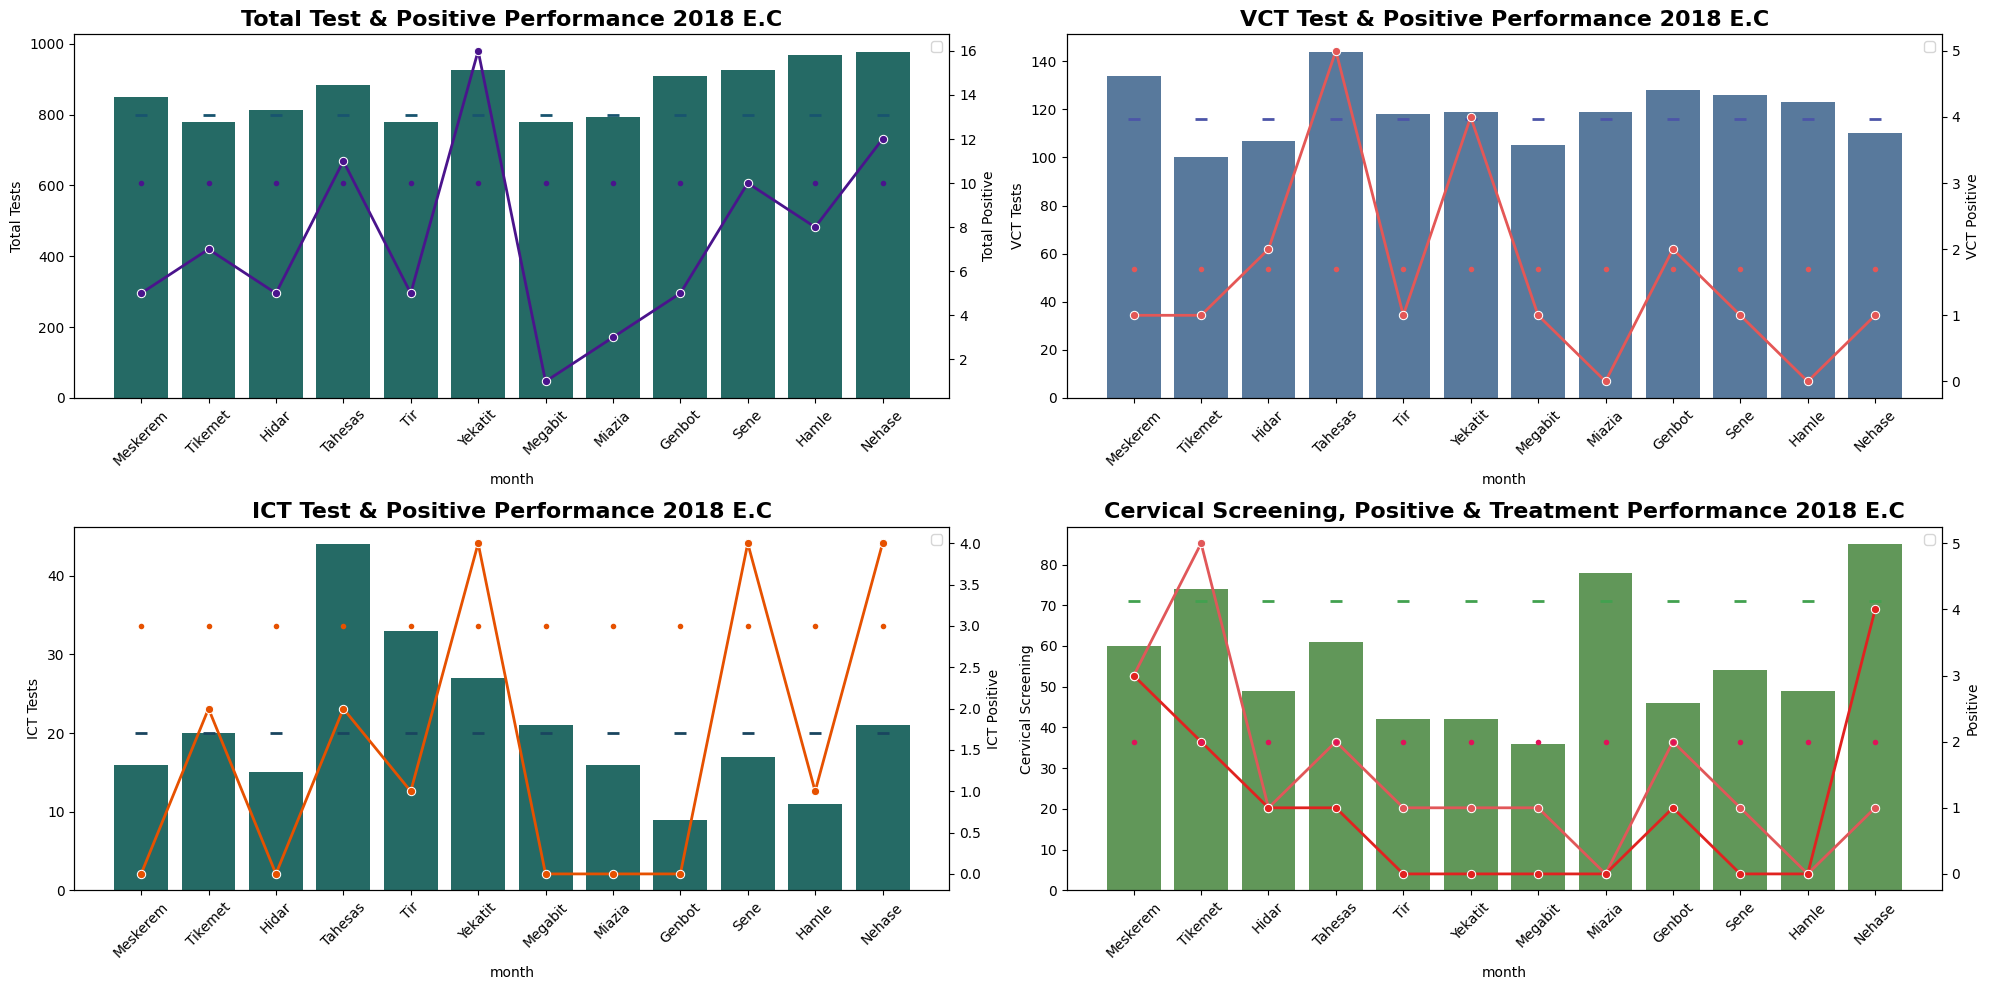

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(20, 10))


# =========================================================
# 1. TOTAL TEST & POSITIVE
# =========================================================

total_test = df['total_test']
total_pos = df['total_pos']

test_target = 800
pos_target = 10

bars = sns.barplot(data=df,x='month',y=total_test,ax=axes[0, 0],color='#19766F')

ax2 = axes[0, 0].twinx()

sns.lineplot(data=df,x='month',y=total_pos,marker='o',color='#4A148C',ax=ax2,linewidth=2)

# ---- Test target dots/dashes on bars ----
for bar in bars.patches:
    x = bar.get_x()
    width = bar.get_width()

    axes[0, 0].plot(
        x + width / 2,
        test_target,
        marker='_',
        markersize=8,
        markeredgewidth=2,
        color='#18546F'
    )

# ---- Positive target dots on secondary axis ----
for x in range(len(total_pos)):
    ax2.plot(
        x,
        pos_target,
        marker='o',
        markersize=2,
        markeredgewidth=2,
        color='#4A148C'
    )

axes[0, 0].set_ylabel('Total Tests')
ax2.set_ylabel('Total Positive')

axes[0, 0].set_title('Total Test & Positive Performance 2018 E.C',fontsize=16,fontweight='bold',fontname='Times New Roman')

axes[0, 0].tick_params(axis='x', rotation=45)

plt.legend()
# =========================================================
# 2. VCT
# =========================================================

vct_test = df['VCT']
vct_pos = df['VCT_Pos']

vct_test_target = 116
vct_pos_target = 1.7

bars = sns.barplot(data=df,x='month', y=vct_test,ax=axes[0, 1],color='#4C78A8')
plt.legend()
ax2 = axes[0, 1].twinx()

sns.lineplot(data=df,x='month', y=vct_pos,marker='o',color='#E45756',ax=ax2,linewidth=2)

plt.legend()
# ---- VCT Test target ----
for bar in bars.patches:
    x = bar.get_x()
    width = bar.get_width()

    axes[0, 1].plot(x + width / 2,vct_test_target,marker='_',markersize=8,markeredgewidth=2,color='#4C55A8')

# ---- VCT Positive target ----
for x in range(len(vct_pos)):
    ax2.plot(
        x,
        vct_pos_target,
        marker='o',
        markersize=2,
        markeredgewidth=2,
        color='#E45756'
    )

axes[0, 1].set_ylabel('VCT Tests')
ax2.set_ylabel('VCT Positive')

axes[0, 1].set_title('VCT Test & Positive Performance 2018 E.C',fontsize=16,fontweight='bold',fontname='Times New Roman')

axes[0, 1].tick_params(axis='x', rotation=45)

# =========================================================
# 3. ICT
# =========================================================

ict_test = df['ICT_Testd']
ict_pos = df['ICT_Pos']

ict_test_target = 20
ict_pos_target = 3

bars = sns.barplot(data =df, x='month',y = ict_test,ax=axes[1, 0],color='#19766F')

ax2 = axes[1, 0].twinx()
sns.lineplot(data =df, x='month',y = ict_pos,ax=ax2,linewidth=2,marker='o',color='#E65100')

plt.legend()
# ---- ICT Test target ----
for bar in bars.patches:
    x = bar.get_x()
    width = bar.get_width()

    axes[1, 0].plot(x + width / 2,ict_test_target,marker='_',markersize=8,markeredgewidth=2,color='#19455F')

# ---- ICT Positive target ----
for x in range(len(ict_pos)):
    ax2.plot(
        x,
        ict_pos_target,
        marker='o',
        markersize=2,
        markeredgewidth=2,
        color='#E65100'
    )

axes[1, 0].set_ylabel('ICT Tests')
ax2.set_ylabel('ICT Positive')

axes[1, 0].set_title('ICT Test & Positive Performance 2018 E.C',fontsize=16,fontweight='bold',fontname='Times New Roman')

axes[1, 0].tick_params(axis='x', rotation=45)


# =========================================================
# 4. CERVICAL SCREENING
# =========================================================

cervical_screen = df['Cervical_screening']
cervical_pos = df['Positive']
cervica_RX = df['Cervical_Treatment']
cervical_target = 71
cervical_pos_target = 2

bars = sns.barplot(data=df, x='month',y = cervical_screen,ax=axes[1, 1],color='#59A14F')

ax2 = axes[1, 1].twinx()

sns.lineplot(data=df,x='month',y=cervical_pos,marker='o', color='#E15759',ax=ax2,linewidth=2)
sns.lineplot(data=df,x='month',y=cervica_RX,marker='o', color='#E12220',ax=ax2,linewidth=2)

plt.legend()
# ---- Cervical screening target ----
for bar in bars.patches:
    x = bar.get_x()
    width = bar.get_width()

    axes[1, 1].plot(x + width / 2,cervical_target,marker='_',markersize=8,markeredgewidth=2,color='#42A14F')

# ---- Cervical positive target ----
for x in range(len(cervical_pos)):
    ax2.plot(
        x,
        cervical_pos_target,
        marker='o',
        markersize=2,
        markeredgewidth=2,
        color='#E11259')

axes[1, 1].set_ylabel('Cervical Screening')
ax2.set_ylabel('Positive')

axes[1, 1].set_title('Cervical Screening, Positive & Treatment Performance 2018 E.C',fontsize=16,fontweight='bold')

axes[1, 1].tick_params(axis='x', rotation=45)


# =========================================================
# COMMON LEGEND
# =========================================================
# Put target legend on the figure
plt.legend()
plt.tight_layout()
plt.show()

# Dashboard

In [ ]:
#renaming the df columns with suffix _dhis since we are going to compare with the ptqit
df.columns = df.columns + '_dhis'


In [ ]:
df.head(12)

,yr_mnth_dhis,VCT_dhis,VCT_Pos_dhis,PITC_dhis,PITC_Pos_dhis,ICT_offered_dhis,Elicited_dhis,ICT_Testd_dhis,ICT_Pos_dhis,ICT_known_dhis,...,HPV_Pos_dhis,Cervical_Treatment_dhis,Cryotherapy_dhis,Treatment with LEEP_dhis,Thermocoagulation_dhis,month_dhis,year_dhis,total_test_dhis,total_pos_dhis,month_gc_dhis
2,Meskerem 2018,134,1,716,4,41,62,16,0,4,...,0,3,0,2,1,Meskerem,2018,850,5,September
3,Tikemet 2018,100,1,679,6,24,43,20,2,13,...,0,2,0,0,2,Tikemet,2018,779,7,October
4,Hidar 2018,107,2,706,3,29,41,15,0,0,...,1,1,0,1,0,Hidar,2018,813,5,November
5,Tahesas 2018,144,5,741,6,45,58,44,2,0,...,0,1,0,0,1,Tahesas,2018,885,11,December
6,Tir 2018,118,1,661,4,35,55,33,1,4,...,0,0,0,0,0,Tir,2018,779,5,January
7,Yekatit 2018,119,4,806,12,41,48,27,4,11,...,0,0,0,0,0,Yekatit,2018,925,16,February
8,Megabit 2018,105,1,675,0,18,25,21,0,0,...,9,0,0,0,0,Megabit,2018,780,1,March
9,Miazia 2018,119,0,675,3,12,13,16,0,0,...,1,0,0,0,0,Miazia,2018,794,3,April
10,Genbot 2018,128,2,781,3,22,30,9,0,4,...,6,1,0,0,1,Genbot,2018,909,5,May
11,Sene 2018,126,1,799,9,39,54,17,4,20,...,16,0,0,0,0,Sene,2018,925,10,June


# PTQIT

In [ ]:
ptqit = pd.read_csv('https://raw.githubusercontent.com/solomon7-data/HIV_DATA1/refs/heads/main/PTQIT.csv')





In [ ]:
ptqit.head()

,dataid,dataname,datacode,datadescription,Meskerem 2018,Tikemet 2018,Hidar 2018,Tahesas 2018,Tir 2018,Yekatit 2018,Megabit 2018,Miazia 2018,Ginbot 2018,Sene 2018,Hamle 2018,Nehase 2018
0,lQqwd8GzF5L,HTS_Inpatient _HIV Tested,HTS_Inpatient_1,NaN,140.0,91.0,88.0,68.0,76.0,59.0,92.0,50.0,106.0,75.0,192.0,178.0
1,fpD5QXzB4z5,HTS_Inpatient_HIV Testeded Positive,HTS_Inpatient_2,NaN,0.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0
2,tE6Cl4fZ8Kb,HTS_Pediatrics OPD _HIV Tested,HTS_Pediatrics OPD_1,NaN,44.0,32.0,25.0,23.0,20.0,22.0,13.0,26.0,24.0,27.0,29.0,28.0
3,YmNd7vNdXIu,HTS_Pediatrics OPD_HIV Testeded Positive,HTS_Pediatrics OPD_2,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
4,dmhF7vG2kf0,HTS_Malnutrition Clinic _HIV Tested,HTS_Malnutrition Clinic_1,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
ptqit = ptqit.drop(columns = ['dataid','datacode','datadescription',])
ptqit.head()

,dataname,Meskerem 2018,Tikemet 2018,Hidar 2018,Tahesas 2018,Tir 2018,Yekatit 2018,Megabit 2018,Miazia 2018,Ginbot 2018,Sene 2018,Hamle 2018,Nehase 2018
0,HTS_Inpatient _HIV Tested,140.0,91.0,88.0,68.0,76.0,59.0,92.0,50.0,106.0,75.0,192.0,178.0
1,HTS_Inpatient_HIV Testeded Positive,0.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0
2,HTS_Pediatrics OPD _HIV Tested,44.0,32.0,25.0,23.0,20.0,22.0,13.0,26.0,24.0,27.0,29.0,28.0
3,HTS_Pediatrics OPD_HIV Testeded Positive,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
4,HTS_Malnutrition Clinic _HIV Tested,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
ptqit = ptqit.set_index('dataname').T
ptqit = ptqit.fillna(0)
ptqit.drop(columns = [ 'HTS_Malnutrition Clinic _HIV Tested',
                      'HTS_Malnutrition Clinic_HIV Testeded Positive',
                      'HTS_STI _HIV Tested',
                      'HTS_STI_HIV Testeded Positive',
                      'HTS_SNS _HIV Tested',
                      'HTS_SNS_HIV Testeded Positive',
                      'HTS_Post ANC1: Breastfeeding _HIV Tested',
                      'HTS_Post ANC1: Breastfeeding_HIV Testeded Positive',])

dataname,HTS_Inpatient _HIV Tested,HTS_Inpatient_HIV Testeded Positive,HTS_Pediatrics OPD _HIV Tested,HTS_Pediatrics OPD_HIV Testeded Positive,HTS_Emergency OPD / WARD _HIV Tested,HTS_Emergency OPD / WARD_HIV Testeded Positive,HTS_VCT _HIV Tested,HTS_VCT_HIV Testeded Positive,HTS_TB _HIV Tested,HTS_TB_HIV Testeded Positive,HTS_Other OPD _HIV Tested,HTS_Other OPD_HIV Testeded Positive,HTS_ANC1 _HIV Tested,HTS_ANC1_HIV Tested Positive,HTS_Post ANC1: Pregnant _HIV Tested,HTS_Post ANC1: Pregnant_HIV Testeded Positive,ICT_ART_Contacts tested,ICT_ART_New tested positive,HTS Total Tested,HTS Total Tested Positive
Meskerem 2018,140.0,0.0,44.0,0.0,119.0,1.0,134.0,1.0,0.0,0.0,369.0,3.0,25.0,0.0,4.0,0.0,15.0,0.0,850.0,5.0
Tikemet 2018,91.0,3.0,32.0,0.0,125.0,2.0,100.0,1.0,1.0,0.0,376.0,0.0,39.0,0.0,4.0,0.0,12.0,1.0,780.0,7.0
Hidar 2018,88.0,1.0,25.0,0.0,135.0,1.0,107.0,2.0,1.0,0.0,398.0,1.0,37.0,0.0,7.0,0.0,15.0,0.0,813.0,5.0
Tahesas 2018,68.0,1.0,23.0,0.0,178.0,4.0,144.0,5.0,1.0,0.0,385.0,0.0,38.0,0.0,7.0,0.0,41.0,1.0,885.0,11.0
Tir 2018,76.0,0.0,20.0,0.0,162.0,2.0,118.0,1.0,0.0,0.0,332.0,1.0,32.0,0.0,4.0,0.0,33.0,1.0,777.0,5.0
Yekatit 2018,59.0,0.0,22.0,1.0,154.0,5.0,119.0,4.0,3.0,0.0,489.0,2.0,47.0,0.0,4.0,0.0,27.0,4.0,924.0,16.0
Megabit 2018,92.0,0.0,13.0,0.0,141.0,0.0,105.0,1.0,1.0,0.0,380.0,0.0,17.0,0.0,6.0,0.0,25.0,0.0,780.0,1.0
Miazia 2018,50.0,0.0,26.0,0.0,139.0,2.0,119.0,0.0,0.0,0.0,408.0,0.0,28.0,0.0,9.0,0.0,16.0,0.0,795.0,2.0
Ginbot 2018,106.0,1.0,24.0,0.0,168.0,1.0,128.0,2.0,1.0,0.0,447.0,1.0,22.0,0.0,1.0,0.0,11.0,0.0,908.0,5.0
Sene 2018,75.0,0.0,27.0,1.0,153.0,1.0,121.0,1.0,2.0,0.0,495.0,1.0,22.0,0.0,10.0,1.0,16.0,6.0,921.0,11.0


In [ ]:
renam_ptqit_cols = {'HTS_Inpatient _HIV Tested':'Inpatient_Tested',
 'HTS_Inpatient_HIV Testeded Positive':'Inpatient_Positive',
 'HTS_Outpatient _HIV Tested':'Outpatient_Tested',
 'HTS_Outpatient_HIV Testeded Positive':'Outpatient_Positive',
 'HTS_Pediatrics OPD _HIV Tested':'Pediatrics_Tested',
 'HTS_Pediatrics OPD_HIV Testeded Positive':'Pediatrics_Positive',
 'HTS_Emergency OPD / WARD _HIV Tested':'Emergency_tested',
 'HTS_Emergency OPD / WARD_HIV Testeded Positive':'Emergency_Positive',
 'HTS_ANC _HIV Tested':'ANC_Tested',
 'HTS_ANC_HIV Testeded Positive':'ANC_Positive',
 'HTS_VCT _HIV Tested':'VCT_Tested',
 'HTS_VCT_HIV Testeded Positive':'VCT_Positive',
 'HTS_TB _HIV Tested':'TB_Tested',
 'HTS_TB_HIV Testeded Positive':'TB_Positive',
 'HTS_Other OPD _HIV Tested':'Other_OPD_Tested',
 'HTS_Other OPD_HIV Testeded Positive':'Other_OPD_Positive',
 'HTS_ANC1 _HIV Tested':'ANC1_Tested',
 'HTS_ANC1_HIV Tested Positive':'ANC1_Pos',
 'HTS_Post ANC1: Pregnant _HIV Tested':'Post_ANC1_Tested',
 'HTS_Post ANC1: Pregnant_HIV Testeded Positive':'Post_ANC1_Pos',
 'ICT_ART_Contacts tested':'Ict_tesed',
 'ICT_ART_New tested positive':'Ict_tesed_positive',
 'HTS_Total Tested':'HTS_Total_Tested',
 'HTS_Total Tested Positive':'HTS_Total_Tested_Positive'}

In [ ]:
ptqit = ptqit.rename(columns=renam_ptqit_cols).reset_index()
ptqit[['month','year']] = ptqit['index'].str.split(' ',expand = True)
ptqit['PITC_test'] = ptqit['HTS Total Tested'] - ptqit['VCT_Tested']
ptqit['PITC_Positive'] = ptqit['HTS Total Tested Positive'] - ptqit['VCT_Positive']

ptqit

dataname,index,Inpatient_Tested,Inpatient_Positive,Pediatrics_Tested,Pediatrics_Positive,HTS_Malnutrition Clinic _HIV Tested,HTS_Malnutrition Clinic_HIV Testeded Positive,HTS_STI _HIV Tested,HTS_STI_HIV Testeded Positive,Emergency_tested,...,HTS_Post ANC1: Breastfeeding _HIV Tested,HTS_Post ANC1: Breastfeeding_HIV Testeded Positive,Ict_tesed,Ict_tesed_positive,HTS Total Tested,HTS Total Tested Positive,month,year,PITC_test,PITC_Positive
0,Meskerem 2018,140.0,0.0,44.0,0.0,0.0,0.0,0.0,0.0,119.0,...,0.0,0.0,15.0,0.0,850.0,5.0,Meskerem,2018,716.0,4.0
1,Tikemet 2018,91.0,3.0,32.0,0.0,0.0,0.0,0.0,0.0,125.0,...,0.0,0.0,12.0,1.0,780.0,7.0,Tikemet,2018,680.0,6.0
2,Hidar 2018,88.0,1.0,25.0,0.0,0.0,0.0,0.0,0.0,135.0,...,0.0,0.0,15.0,0.0,813.0,5.0,Hidar,2018,706.0,3.0
3,Tahesas 2018,68.0,1.0,23.0,0.0,0.0,0.0,0.0,0.0,178.0,...,0.0,0.0,41.0,1.0,885.0,11.0,Tahesas,2018,741.0,6.0
4,Tir 2018,76.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,162.0,...,0.0,0.0,33.0,1.0,777.0,5.0,Tir,2018,659.0,4.0
5,Yekatit 2018,59.0,0.0,22.0,1.0,0.0,0.0,0.0,0.0,154.0,...,0.0,0.0,27.0,4.0,924.0,16.0,Yekatit,2018,805.0,12.0
6,Megabit 2018,92.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,141.0,...,0.0,0.0,25.0,0.0,780.0,1.0,Megabit,2018,675.0,0.0
7,Miazia 2018,50.0,0.0,26.0,0.0,0.0,0.0,0.0,0.0,139.0,...,0.0,0.0,16.0,0.0,795.0,2.0,Miazia,2018,676.0,2.0
8,Ginbot 2018,106.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,168.0,...,0.0,0.0,11.0,0.0,908.0,5.0,Ginbot,2018,780.0,3.0
9,Sene 2018,75.0,0.0,27.0,1.0,0.0,0.0,0.0,0.0,153.0,...,0.0,0.0,16.0,6.0,921.0,11.0,Sene,2018,800.0,10.0


In [ ]:
integer = ['Inpatient_Tested', 'Inpatient_Positive', 'Pediatrics_Tested',
       'Pediatrics_Positive', 'HTS_Malnutrition Clinic _HIV Tested',
       'HTS_Malnutrition Clinic_HIV Testeded Positive', 'HTS_STI _HIV Tested',
       'HTS_STI_HIV Testeded Positive', 'Emergency_tested',
       'Emergency_Positive', 'HTS_SNS _HIV Tested',
       'HTS_SNS_HIV Testeded Positive', 'VCT_Tested', 'VCT_Positive',
       'TB_Tested', 'TB_Positive', 'Other_OPD_Tested', 'Other_OPD_Positive',
       'ANC1_Tested', 'ANC1_Pos', 'Post_ANC1_Tested', 'Post_ANC1_Pos',
       'HTS_Post ANC1: Breastfeeding _HIV Tested',
       'HTS_Post ANC1: Breastfeeding_HIV Testeded Positive', 'Ict_tesed',
       'Ict_tesed_positive', 'HTS Total Tested', 'HTS Total Tested Positive',
       'PITC_test', 'PITC_Positive']
ptqit[integer] = ptqit[integer].apply(pd.to_numeric, errors='coerce').astype('Int64')

In [ ]:
compare = pd.merge(ptqit[['VCT_Tested', 'VCT_Positive',
                          'TB_Tested', 'TB_Positive',
                          'ANC1_Tested', 'ANC1_Pos',
                          'Post_ANC1_Tested', 'Post_ANC1_Pos',
                          'Ict_tesed','Ict_tesed_positive',
                          'HTS Total Tested', 'HTS Total Tested Positive',
                          'PITC_test', 'PITC_Positive',
                          'month', 'year']],
              df[['VCT_dhis', 'VCT_Pos_dhis', 'PITC_dhis', 'PITC_Pos_dhis', 'ICT_offered_dhis', 'Elicited_dhis', 'ICT_Testd_dhis', 'ICT_Pos_dhis',
                 'ICT_known_dhis', 'Self_Test_dhis', 'TX_New_dhis', 'Linked_dhis', 'Initiated_dhis', 'known_dhis', 'Lost_dhis', 'Referred_dhis',
                 'Died_dhis', 'Others_dhis', 'Other_DSD_dhis', 'AHD_dhis', 'Number of ART clients restarted ARV treatment in the reporting period_dhis',
                 'Number of individuals receiving Pre-Exposure Prophylaxis_dhis', 'PrEP (New individuals newly enrolled on PrEP) by age and Sex_dhis',
                 'PrEP (New individuals newly enrolled on PrEP) by Client Category_dhis', 'Discordant Couple_dhis', 'CSW_1_dhis', 'PrEP_dhis',
                 'Prep_Curr_dhis', 'By Client Category_dhis', 'TB_Screened_dhis', 'TB_Screened_new_dhis', 'Presumptive_TB_dhis',
                 'Number of PLHIVs PREVIOUSLY on ART and screened for TB_dhis', 'TB_RX_dhis', 'month_dhis', 'year_dhis']],

              left_on=['month','year'],
              right_on=['month_dhis','year_dhis'],
              how='left')

In [ ]:
# sort order of columns
compare = compare[['month', 'year','HTS Total Tested', 'HTS Total Tested Positive','PITC_test','PITC_dhis','PITC_Positive','PITC_Pos_dhis','VCT_Tested','VCT_dhis','VCT_Positive','VCT_Pos_dhis',
                          'Ict_tesed','ICT_Testd_dhis','Ict_tesed_positive','ICT_Pos_dhis',
                          'ANC1_Tested', 'ANC1_Pos','ICT_offered_dhis', 'Elicited_dhis',
                 'ICT_known_dhis', 'Self_Test_dhis', 'TX_New_dhis', 'Post_ANC1_Tested', 'Post_ANC1_Pos',
                          'TB_Tested', 'TB_Positive','Linked_dhis', 'Initiated_dhis', 'known_dhis', 'Lost_dhis', 'Referred_dhis',
                 'Died_dhis', 'Others_dhis', 'Other_DSD_dhis', 'AHD_dhis', 'Number of ART clients restarted ARV treatment in the reporting period_dhis',
                 'Number of individuals receiving Pre-Exposure Prophylaxis_dhis', 'PrEP (New individuals newly enrolled on PrEP) by age and Sex_dhis',
                 'PrEP (New individuals newly enrolled on PrEP) by Client Category_dhis', 'Discordant Couple_dhis', 'CSW_1_dhis', 'PrEP_dhis',
                 'Prep_Curr_dhis', 'By Client Category_dhis', 'TB_Screened_dhis', 'TB_Screened_new_dhis', 'Presumptive_TB_dhis',
                 'Number of PLHIVs PREVIOUSLY on ART and screened for TB_dhis', 'TB_RX_dhis','month_dhis', 'year_dhis']]


In [ ]:
pairs = [('VCT_Tested','VCT_dhis'), ('VCT_Positive','VCT_Pos_dhis'),('PITC_test','PITC_dhis'),('PITC_Positive','PITC_Pos_dhis'),
        ('TB_Tested','TB_Screened_dhis'), ('TB_Positive','TB_Screened_new_dhis'),
       ('Ict_tesed','ICT_Testd_dhis'), ('Ict_tesed_positive','ICT_Pos_dhis')]

def highlight_differences(row):
    styles = pd.Series('', index=row.index)
    for col1, col2 in pairs:
        a, b = row[col1], row[col2]
        if pd.notna(a) and pd.notna(b) and a != b:
            styles[col1] = 'color: red; font-weight: bold'
            styles[col2] = 'color: red; font-weight: bold'
    return styles

compare.round(0).style.apply(highlight_differences, axis=1)

,month,year,HTS Total Tested,HTS Total Tested Positive,PITC_test,PITC_dhis,PITC_Positive,PITC_Pos_dhis,VCT_Tested,VCT_dhis,VCT_Positive,VCT_Pos_dhis,Ict_tesed,ICT_Testd_dhis,Ict_tesed_positive,ICT_Pos_dhis,ANC1_Tested,ANC1_Pos,ICT_offered_dhis,Elicited_dhis,ICT_known_dhis,Self_Test_dhis,TX_New_dhis,Post_ANC1_Tested,Post_ANC1_Pos,TB_Tested,TB_Positive,Linked_dhis,Initiated_dhis,known_dhis,Lost_dhis,Referred_dhis,Died_dhis,Others_dhis,Other_DSD_dhis,AHD_dhis,Number of ART clients restarted ARV treatment in the reporting period_dhis,Number of individuals receiving Pre-Exposure Prophylaxis_dhis,PrEP (New individuals newly enrolled on PrEP) by age and Sex_dhis,PrEP (New individuals newly enrolled on PrEP) by Client Category_dhis,Discordant Couple_dhis,CSW_1_dhis,PrEP_dhis,Prep_Curr_dhis,By Client Category_dhis,TB_Screened_dhis,TB_Screened_new_dhis,Presumptive_TB_dhis,Number of PLHIVs PREVIOUSLY on ART and screened for TB_dhis,TB_RX_dhis,month_dhis,year_dhis
0,Meskerem,2018,850,5,716,716,4,4,134,134,1,1,15,16,0,0,25,0,41,62,4,19,7,4,0,0,0,9,7,0,0,0,1,1,124,207,8,0,2,2,2,0,0,5,5,0,7,1,,8,Meskerem,2018
1,Tikemet,2018,780,7,680,679,6,6,100,100,1,1,12,20,1,2,39,0,24,43,13,5,10,4,0,1,0,10,9,0,0,0,0,1,122,216,4,0,1,1,0,1,0,3,3,0,10,2,2,9,Tikemet,2018
2,Hidar,2018,813,5,706,706,3,3,107,107,2,2,15,15,0,0,37,0,29,41,0,17,9,7,0,1,0,9,9,0,0,0,0,0,119,220,9,0,0,0,0,0,0,5,5,0,10,5,,10,Hidar,2018
3,Tahesas,2018,885,11,741,741,6,6,144,144,5,5,41,44,1,2,38,0,45,58,0,39,13,7,0,1,0,11,10,0,0,0,0,1,113,231,4,0,3,3,3,0,0,3,3,0,16,4,,8,Tahesas,2018
4,Tir,2018,777,5,659,661,4,4,118,118,1,1,33,33,1,1,32,0,35,55,4,31,4,4,0,0,0,7,4,0,0,0,1,2,111,234,6,0,2,2,2,0,0,5,6,0,5,0,,4,Tir,2018
5,Yekatit,2018,924,16,805,806,12,12,119,119,4,4,27,27,4,4,47,0,41,48,11,2,14,4,0,3,0,18,13,1,0,0,3,1,109,244,7,0,1,1,1,0,0,8,8,0,13,2,,10,Yekatit,2018
6,Megabit,2018,780,1,675,675,0,0,105,105,1,1,25,21,0,0,17,0,18,25,0,7,3,6,0,1,0,4,4,0,0,0,0,0,105,246,5,0,2,2,1,1,0,5,5,0,4,2,,2,Megabit,2018
7,Miazia,2018,795,2,676,675,2,3,119,119,0,0,16,16,0,0,28,0,12,13,0,0,2,9,0,0,0,4,2,0,0,0,0,2,104,249,10,0,1,1,0,1,0,4,4,0,2,2,,3,Miazia,2018
8,Ginbot,2018,908,5,780,,3,,128,,2,,11,,0,,22,0,,,,,,1,0,1,0,,,,,,,,,,,,,,,,,,,,,,,,nan,nan
9,Sene,2018,921,11,800,799,10,9,121,126,1,1,16,17,6,4,22,0,39,54,20,13,11,10,1,2,0,14,9,0,0,1,0,4,97,262,7,0,0,0,0,0,0,3,3,0,11,2,,6,Sene,2018


In [ ]:
from IPython.display import display

pairs = [('VCT_Tested','VCT_dhis'), ('VCT_Positive','VCT_Pos_dhis'),('PITC_test','PITC_dhis'),('PITC_Positive','PITC_Pos_dhis'),
        ('TB_Tested','TB_Screened_dhis'), ('TB_Positive','TB_Screened_new_dhis'),
       ('Ict_tesed','ICT_Testd_dhis'), ('Ict_tesed_positive','ICT_Pos_dhis')]

def highlight_differences(row):
    styles = pd.Series('', index=row.index)

    for col1, col2 in pairs:
        a, b = row[col1], row[col2]

        if pd.notna(a) and pd.notna(b) and a != b:
            styles[col1] = 'color: red; font-weight: bold'
            styles[col2] = 'color: red; font-weight: bold'

    return styles

styled_compare  = display(compare.style.apply(highlight_differences, axis=1))

,month,year,HTS Total Tested,HTS Total Tested Positive,PITC_test,PITC_dhis,PITC_Positive,PITC_Pos_dhis,VCT_Tested,VCT_dhis,VCT_Positive,VCT_Pos_dhis,Ict_tesed,ICT_Testd_dhis,Ict_tesed_positive,ICT_Pos_dhis,ANC1_Tested,ANC1_Pos,ICT_offered_dhis,Elicited_dhis,ICT_known_dhis,Self_Test_dhis,TX_New_dhis,Post_ANC1_Tested,Post_ANC1_Pos,TB_Tested,TB_Positive,Linked_dhis,Initiated_dhis,known_dhis,Lost_dhis,Referred_dhis,Died_dhis,Others_dhis,Other_DSD_dhis,AHD_dhis,Number of ART clients restarted ARV treatment in the reporting period_dhis,Number of individuals receiving Pre-Exposure Prophylaxis_dhis,PrEP (New individuals newly enrolled on PrEP) by age and Sex_dhis,PrEP (New individuals newly enrolled on PrEP) by Client Category_dhis,Discordant Couple_dhis,CSW_1_dhis,PrEP_dhis,Prep_Curr_dhis,By Client Category_dhis,TB_Screened_dhis,TB_Screened_new_dhis,Presumptive_TB_dhis,Number of PLHIVs PREVIOUSLY on ART and screened for TB_dhis,TB_RX_dhis,month_dhis,year_dhis
0,Meskerem,2018,850,5,716,716,4,4,134,134,1,1,15,16,0,0,25,0,41,62,4,19,7,4,0,0,0,9,7,0,0,0,1,1,124,207,8,0,2,2,2,0,0,5,5,0,7,1,,8,Meskerem,2018
1,Tikemet,2018,780,7,680,679,6,6,100,100,1,1,12,20,1,2,39,0,24,43,13,5,10,4,0,1,0,10,9,0,0,0,0,1,122,216,4,0,1,1,0,1,0,3,3,0,10,2,2,9,Tikemet,2018
2,Hidar,2018,813,5,706,706,3,3,107,107,2,2,15,15,0,0,37,0,29,41,0,17,9,7,0,1,0,9,9,0,0,0,0,0,119,220,9,0,0,0,0,0,0,5,5,0,10,5,,10,Hidar,2018
3,Tahesas,2018,885,11,741,741,6,6,144,144,5,5,41,44,1,2,38,0,45,58,0,39,13,7,0,1,0,11,10,0,0,0,0,1,113,231,4,0,3,3,3,0,0,3,3,0,16,4,,8,Tahesas,2018
4,Tir,2018,777,5,659,661,4,4,118,118,1,1,33,33,1,1,32,0,35,55,4,31,4,4,0,0,0,7,4,0,0,0,1,2,111,234,6,0,2,2,2,0,0,5,6,0,5,0,,4,Tir,2018
5,Yekatit,2018,924,16,805,806,12,12,119,119,4,4,27,27,4,4,47,0,41,48,11,2,14,4,0,3,0,18,13,1,0,0,3,1,109,244,7,0,1,1,1,0,0,8,8,0,13,2,,10,Yekatit,2018
6,Megabit,2018,780,1,675,675,0,0,105,105,1,1,25,21,0,0,17,0,18,25,0,7,3,6,0,1,0,4,4,0,0,0,0,0,105,246,5,0,2,2,1,1,0,5,5,0,4,2,,2,Megabit,2018
7,Miazia,2018,795,2,676,675,2,3,119,119,0,0,16,16,0,0,28,0,12,13,0,0,2,9,0,0,0,4,2,0,0,0,0,2,104,249,10,0,1,1,0,1,0,4,4,0,2,2,,3,Miazia,2018
8,Ginbot,2018,908,5,780,,3,,128,,2,,11,,0,,22,0,,,,,,1,0,1,0,,,,,,,,,,,,,,,,,,,,,,,,nan,nan
9,Sene,2018,921,11,800,799,10,9,121,126,1,1,16,17,6,4,22,0,39,54,20,13,11,10,1,2,0,14,9,0,0,1,0,4,97,262,7,0,0,0,0,0,0,3,3,0,11,2,,6,Sene,2018


# Data Consistency

In [ ]:
#from google.colab import files

# Re-create the styled object directly
styled_table = compare.style.apply(highlight_differences, axis=1)

# Export the styled table directly to Excel to retain the conditional formatting
styled_table.to_excel('dhisVsPTQIT.xlsx', index=False, engine='openpyxl')

# Download the file locally
#files.download('dhisVsPTQIT.xlsx')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Meskerem'),
  Text(1, 0, 'Tikemet'),
  Text(2, 0, 'Hidar'),
  Text(3, 0, 'Tahesas'),
  Text(4, 0, 'Tir'),
  Text(5, 0, 'Yekatit'),
  Text(6, 0, 'Megabit'),
  Text(7, 0, 'Miazia'),
  Text(8, 0, 'Genbot'),
  Text(9, 0, 'Sene'),
  Text(10, 0, 'Hamle'),
  Text(11, 0, 'Nehase')])

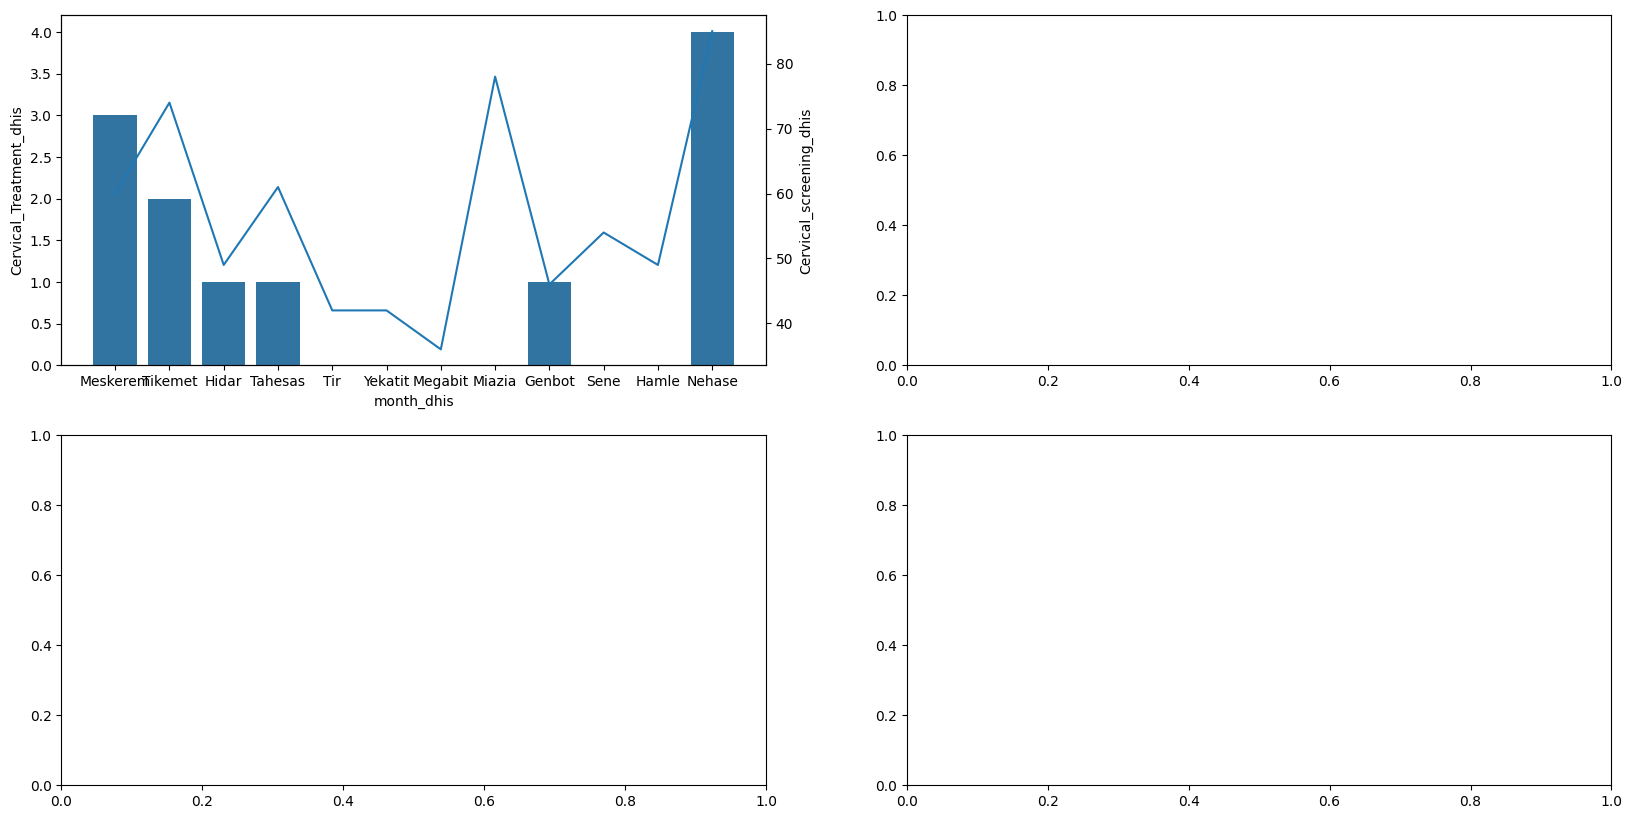

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(20, 10))
ax1 =axes[0, 0]

sns.barplot(data = df,x = 'month_dhis' ,y= 'Cervical_Treatment_dhis',ax=ax1)
ax2 = ax1.twinx()
sns.lineplot(data = df,x = 'month_dhis' ,y= 'Cervical_screening_dhis',ax=ax2)

plt.xticks(rotation=45)